# Sales Forecasting System

#### Library Imports

## Library imports

This cell imports the libraries used for data manipulation, visualization, preprocessing, evaluation, and XGBoost model training.

In [46]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection._split import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OrdinalEncoder

import xgboost as xgb

### Datasets loading

## Dataset loading

This cell loads the training data, test data, store information, transactions, oil prices, and holiday events used in the sales forecasting project.

In [47]:
train = pd.read_csv("/kaggle/input/competitions/Store-Sales-Forecasting/train.csv")
stores = pd.read_csv("/kaggle/input/competitions/Store-Sales-Forecasting/stores.csv")
transactions = pd.read_csv("/kaggle/input/competitions/Store-Sales-Forecasting/transactions.csv")
oil = pd.read_csv("/kaggle/input/competitions/Store-Sales-Forecasting/oil.csv")
holidays_events = pd.read_csv("/kaggle/input/competitions/Store-Sales-Forecasting/holidays_events.csv")
test = pd.read_csv("/kaggle/input/competitions/Store-Sales-Forecasting/test.csv")

print("shape of train data", train.shape)
print("shape of stores data ", stores.shape)
print("shape of transactions data", transactions.shape)
print("shape of oil data", oil.shape)
print("shape of holidays_events data", holidays_events.shape)
print("shape of test data", test.shape)

shape of train data (3000888, 6)
shape of stores data  (54, 5)
shape of transactions data (83488, 3)
shape of oil data (1218, 2)
shape of holidays_events data (350, 6)
shape of test data (28512, 5)


### See the raw data

## Raw data inspection

This cell displays the first rows and descriptive statistics of every dataset to understand their structure, columns, data types, and possible missing values.

In [48]:
dataset_list = {
    "train": train, 
    "store": stores, 
    "transactions": transactions, 
    "oil": oil, 
    "holidays_events": holidays_events,
    "test": test
}
for name in dataset_list:
    print(name)
    print('-'*5)
    display(dataset_list[name].head())
    display(dataset_list[name].describe(include="all"))
    print('-'*50)
    

train
-----


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


,id,date,store_nbr,family,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3000888,3.000888e+06,3.000888e+06
unique,NaN,1684,NaN,33,NaN,NaN
top,NaN,2017-08-15,NaN,AUTOMOTIVE,NaN,NaN
freq,NaN,1782,NaN,90936,NaN,NaN
mean,1.500444e+06,NaN,2.750000e+01,NaN,3.577757e+02,2.602770e+00
std,8.662819e+05,NaN,1.558579e+01,NaN,1.101998e+03,1.221888e+01
min,0.000000e+00,NaN,1.000000e+00,NaN,0.000000e+00,0.000000e+00
25%,7.502218e+05,NaN,1.400000e+01,NaN,0.000000e+00,0.000000e+00
50%,1.500444e+06,NaN,2.750000e+01,NaN,1.100000e+01,0.000000e+00
75%,2.250665e+06,NaN,4.100000e+01,NaN,1.958473e+02,0.000000e+00


--------------------------------------------------
store
-----


,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


...

,date,type,locale,locale_name,description,transferred
count,350,350,350,350,350,350
unique,312,6,3,24,103,2
top,2014-06-25,Holiday,National,Ecuador,Carnaval,False
freq,4,221,174,174,10,338


--------------------------------------------------
test
-----


,id,date,store_nbr,family,onpromotion
0,3000888,2017-08-16,1,AUTOMOTIVE,0
1,3000889,2017-08-16,1,BABY CARE,0
2,3000890,2017-08-16,1,BEAUTY,2
3,3000891,2017-08-16,1,BEVERAGES,20
4,3000892,2017-08-16,1,BOOKS,0


,id,date,store_nbr,family,onpromotion
count,2.851200e+04,28512,28512.000000,28512,28512.000000
unique,NaN,16,NaN,33,NaN
top,NaN,2017-08-16,NaN,AUTOMOTIVE,NaN
freq,NaN,1782,NaN,864,NaN
mean,3.015144e+06,NaN,27.500000,NaN,6.965383
std,8.230850e+03,NaN,15.586057,NaN,20.683952
min,3.000888e+06,NaN,1.000000,NaN,0.000000
25%,3.008016e+06,NaN,14.000000,NaN,0.000000
50%,3.015144e+06,NaN,27.500000,NaN,0.000000
75%,3.022271e+06,NaN,41.000000,NaN,6.000000


--------------------------------------------------


### Data preprocessing

## Data merging and initial preprocessing

This cell combines the training and test datasets, then joins store information, transactions, and oil prices using their common keys.

In [49]:
df = pd.concat([train, test], axis=0)
df = pd.merge(df, stores, on="store_nbr", how="left")
df = df.merge(transactions, on=['date', 'store_nbr'], how='left')

oil = oil.rename(columns={'dcoilwtico': 'oil_price'})
df = df.merge(oil, on='date', how='left')
df = df.sort_values(['store_nbr', 'family', 'date'])   # tri indispensable pour des lags corrects
df['oil_price'] = df['oil_price'].ffill().bfill()

## Holiday indicators

This cell identifies national, regional, and local holidays and creates indicators showing whether a holiday applies to each store on a given date.

In [50]:
national_holidays = holidays_events[(holidays_events['locale'] == 'National') &
    (holidays_events['transferred'] == False)]['date'].unique()

regional_holidays = (holidays_events[(holidays_events['locale'] == 'Regional') &
    (holidays_events['transferred'] == False)]
    .groupby('date')['locale_name'].apply(set).to_dict())

local_holidays = (holidays_events[(holidays_events['locale'] == 'Local') &
    (holidays_events['transferred'] == False)]
    .groupby('date')['locale_name'].apply(set).to_dict())

df['is_nat_holiday'] = df['date'].isin(national_holidays).astype(int)
df['is_reg_holiday'] = df.apply(
    lambda r: int(r['state'] in regional_holidays.get(r['date'], set())), axis=1
)
df['is_loc_holiday'] = df.apply(
    lambda r: int(r['city'] in local_holidays.get(r['date'], set())), axis=1
)

## Date normalization

This cell converts the date columns to a consistent datetime format so that temporal features and joins can be calculated correctly.

In [51]:
# normalize date column for coherence
df['date'] = pd.to_datetime(df['date']).dt.normalize()
holidays_events['date'] = pd.to_datetime(holidays_events['date']).dt.normalize()
df['date'] = pd.to_datetime(df['date'])

## Time-based features

This cell extracts the year, month, day, day of the week, and weekend indicator from each date.

In [52]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

## Processed data overview

This cell displays descriptive statistics after the preprocessing steps have been completed.

In [53]:
df.describe(include="all")

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,transactions,oil_price,is_nat_holiday,is_reg_holiday,is_loc_holiday,year,month,day,dayofweek,is_weekend
count,3.029400e+06,3029400,3.029400e+06,3029400,3.000888e+06,3.029400e+06,3029400,3029400,3029400,3.029400e+06,2.755104e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06,3.029400e+06
unique,NaN,NaN,NaN,33,NaN,NaN,22,16,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,AUTOMOTIVE,NaN,NaN,Quito,Pichincha,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,91800,NaN,NaN,1009800,1065900,1009800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.514700e+06,2015-05-02 08:56:11.294117376,2.750000e+01,NaN,3.577757e+02,2.643830e+00,NaN,NaN,NaN,8.481481e+00,1.694602e+03,6.770534e+01,8.000000e-02,3.376906e-04,3.943355e-03,2.014858e+03,6.224706e+00,1.570412e+01,2.996471e+00,2.852941e-01
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,1.000000e+00,5.000000e+00,2.619000e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.013000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.573498e+05,2014-03-02 18:00:00,1.400000e+01,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,4.000000e+00,1.046000e+03,4.640750e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.014000e+03,3.000000e+00,8.000000e+00,1.000000e+00,0.000000e+00
50%,1.514700e+06,2015-05-02 12:00:00,2.750000e+01,NaN,1.100000e+01,0.000000e+00,NaN,NaN,NaN,8.500000e+00,1.393000e+03,5.326000e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.015000e+03,6.000000e+00,1.600000e+01,3.000000e+00,0.000000e+00
75%,2.272049e+06,2016-07-01 06:00:00,4.100000e+01,NaN,1.958473e+02,0.000000e+00,NaN,NaN,NaN,1.300000e+01,2.079000e+03,9.571000e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.016000e+03,9.000000e+00,2.300000e+01,5.000000e+00,1.000000e+00
max,3.029399e+06,2017-08-31 00:00:00,5.400000e+01,NaN,1.247170e+05,7.410000e+02,NaN,NaN,NaN,1.700000e+01,8.359000e+03,1.106200e+02,1.000000e+00,1.000000e+00,1.000000e+00,2.017000e+03,1.200000e+01,3.100000e+01,6.000000e+00,1.000000e+00


## Holiday categorization

This function groups holiday descriptions into meaningful categories such as Christmas, Carnival, shopping events, and national celebrations.

In [54]:
def categorize_holiday(desc):
    if pd.isna(desc):
        return 'none'
    d = desc.lower()
    
    # 1. Décalages / ponts (les plus spécifiques d'abord)
    if 'traslado' in d or 'recupero' in d or 'puente' in d:
        return 'moved'
    
    # 2. Catastrophes naturelles
    if 'terremoto' in d:
        return 'earthquake'
    
    # 3. Événements sportifs
    if 'mundial' in d:
        return 'world_cup'
    
    # 4. Événements commerciaux
    if 'black friday' in d or 'cyber monday' in d:
        return 'shopping'
    
    # 5. Fêtes majeures
    if 'navidad' in d:
        return 'christmas'
    if 'carnaval' in d:
        return 'carnival'
    if 'viernes santo' in d:
        return 'good_friday'
    if 'primer dia del ano' in d:
        return 'new_year'
    if 'grito' in d:
        return 'independence_cry'
    
    # 6. Fêtes nationales
    if 'independencia' in d:
        return 'independence'
    if 'batalla' in d:
        return 'battle'
    if 'trabajo' in d:
        return 'labor_day'
    if 'difuntos' in d:
        return 'deceased'
    if 'madre' in d:
        return 'mothers_day'
    
    # 7. Fêtes locales (fondations / anniversaires)
    if 'fundacion' in d:
        return 'foundation'
    if 'cantonizacion' in d or 'provincializacion' in d:
        return 'regional_anniv'
    
    return 'other'

holidays_events['category'] = holidays_events['description'].apply(categorize_holiday)

## Holiday category features

This cell creates binary columns for the different holiday categories so the model can learn their impact on sales.

In [57]:
categorize_holiday_col_list = []
for cat in holidays_events['category'].unique():
    if cat == 'none':
        continue
    dates = holidays_events[holidays_events['category'] == cat]['date'].unique()
    df[f'is_{cat}'] = df['date'].isin(dates).astype(int)
    categorize_holiday_col_list.append(f'is_{cat}')
print(categorize_holiday_col_list)

['is_foundation', 'is_regional_anniv', 'is_independence_cry', 'is_independence', 'is_moved', 'is_deceased', 'is_christmas', 'is_new_year', 'is_carnival', 'is_good_friday', 'is_labor_day', 'is_mothers_day', 'is_battle', 'is_world_cup', 'is_shopping', 'is_earthquake']


## Lag and rolling features

This cell creates lagged sales and transaction variables, as well as rolling averages, to represent recent historical demand without using future information.

In [58]:
grp_sales = df.groupby(['store_nbr', 'family'])['sales']
grp_trans = df.groupby(['store_nbr', 'family'])['transactions']

# Le test fait 16 jours : un lag de 16 pointe, dans le PIRE des cas (dernier jour du test),
# exactement sur le dernier jour connu du train -> jamais de fuite, jamais de NaN à combler artificiellement
df['sales_lag_16']  = grp_sales.shift(16)
df['sales_lag_21']  = grp_sales.shift(21)
df['sales_lag_28']  = grp_sales.shift(28)

# moyennes mobiles calculées SUR la série déjà décalée de 16j -> toujours valides
df['sales_roll_mean_7_lag16']  = grp_sales.shift(16).rolling(7).mean()
df['sales_roll_mean_28_lag16'] = grp_sales.shift(16).rolling(28).mean()

df['transactions_lag_16']       = grp_trans.shift(16)
df['transactions_roll_mean_7_lag16'] = grp_trans.shift(16).rolling(7).mean()


## Categorical data preparation

This cell identifies categorical columns and prepares them for use with the XGBoost model.

In [59]:
cat_col = ["family", "city", "state", "type"]

for col in cat_col:
    if col in df.columns:
        df[col] = df[col].astype("category")

In [60]:
df.describe(include="all")

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,...,is_world_cup,is_shopping,is_earthquake,sales_lag_16,sales_lag_21,sales_lag_28,sales_roll_mean_7_lag16,sales_roll_mean_28_lag16,transactions_lag_16,transactions_roll_mean_7_lag16
count,3.029400e+06,3029400,3.029400e+06,3029400,3.000888e+06,3.029400e+06,3029400,3029400,3029400,3.029400e+06,...,3.029400e+06,3.029400e+06,3.029400e+06,3.000888e+06,2.991978e+06,2.979504e+06,2.990196e+06,2.952774e+06,2.755104e+06,2.701050e+06
unique,NaN,NaN,NaN,33,NaN,NaN,22,16,5,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,AUTOMOTIVE,NaN,NaN,Quito,Pichincha,D,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,91800,NaN,NaN,1009800,1065900,1009800,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.514700e+06,2015-05-02 08:56:11.294117376,2.750000e+01,NaN,3.577757e+02,2.643830e+00,NaN,NaN,NaN,8.481481e+00,...,8.235294e-03,3.529412e-03,1.823529e-02,3.577757e+02,3.575015e+02,3.570705e+02,3.579560e+02,3.582494e+02,1.694602e+03,1.689719e+03
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,4.292857e+02
25%,7.573498e+05,2014-03-02 18:00:00,1.400000e+01,NaN,0.000000e+00,0.000000e+00,NaN,NaN,NaN,4.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.214286e-01,1.046000e+03,1.078000e+03
50%,1.514700e+06,2015-05-02 12:00:00,2.750000e+01,NaN,1.100000e+01,0.000000e+00,NaN,NaN,NaN,8.500000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,1.100000e+01,1.100000e+01,1.100000e+01,1.214286e+01,1.267857e+01,1.393000e+03,1.397143e+03
75%,2.272049e+06,2016-07-01 06:00:00,4.100000e+01,NaN,1.958473e+02,0.000000e+00,NaN,NaN,NaN,1.300000e+01,...,0.000000e+00,0.000000e+00,0.000000e+00,1.958473e+02,1.953108e+02,1.950000e+02,2.032857e+02,2.062732e+02,2.079000e+03,2.062286e+03
max,3.029399e+06,2017-08-31 00:00:00,5.400000e+01,NaN,1.247170e+05,7.410000e+02,NaN,NaN,NaN,1.700000e+01,...,1.000000e+00,1.000000e+00,1.000000e+00,1.247170e+05,1.247170e+05,1.247170e+05,2.993729e+04,1.611832e+04,8.359000e+03,7.184429e+03


## Train and test data preparation

This cell separates observations with known sales from future observations and handles missing values in the historical features.

In [61]:

df_train = df[df['sales'].notna()].copy()
df_test  = df[df['sales'].isna()].copy()

lag_cols = ['sales_lag_16', 'sales_lag_21', 'sales_lag_28',
            'sales_roll_mean_7_lag16', 'sales_roll_mean_28_lag16',
            'transactions_lag_16', 'transactions_roll_mean_7_lag16']

# uniquement pour les tout premiers jours de l'historique (pas assez de recul) -> on peut les jeter du train
df_train.dropna(subset=lag_cols, inplace=True)

# côté test, en théorie il n'y a plus de NaN sur ces colonnes ; par sécurité, on comble
# avec la médiane du même store+family plutôt qu'un ffill qui n'a pas de sens ici
for col in lag_cols:
    df_test[col] = df_test.groupby(['store_nbr', 'family'])[col].transform(
        lambda s: s.fillna(s.median())
    )

/tmp/ipykernel_58/3089795909.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test[col] = df_test.groupby(['store_nbr', 'family'])[col].transform(


## Encoding categorical variables

This cell converts categorical variables into numerical values. Unknown categories are assigned a safe value for prediction.

In [62]:
# 1. Identifier les colonnes catégorielles textuelles
categorical_cols = ['family', 'city', 'state', 'type']

# 2. Initialiser et appliquer l'encoder sur le train et le test
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# On ajuste sur le train et on transforme le train et le test
df_train[categorical_cols] = encoder.fit_transform(df_train[categorical_cols])
df_test[categorical_cols] = encoder.transform(df_test[categorical_cols])

## Prepared training data

This cell previews the prepared training dataset before exploratory analysis and model training.

In [64]:
df_train.head()

,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,...,is_world_cup,is_shopping,is_earthquake,sales_lag_16,sales_lag_21,sales_lag_28,sales_roll_mean_7_lag16,sales_roll_mean_28_lag16,transactions_lag_16,transactions_roll_mean_7_lag16
76626,76626,2013-02-13,1,0.0,0.0,0,18.0,12.0,3.0,13,...,0,0,0,3.0,3.0,1.0,2.571429,2.142857,1738.0,1513.714286
78408,78408,2013-02-14,1,0.0,0.0,0,18.0,12.0,3.0,13,...,0,0,0,2.0,0.0,1.0,2.714286,2.214286,1772.0,1515.142857
80190,80190,2013-02-15,1,0.0,0.0,0,18.0,12.0,3.0,13,...,0,0,0,6.0,5.0,0.0,3.142857,2.357143,1877.0,1515.714286
81972,81972,2013-02-16,1,0.0,1.0,0,18.0,12.0,3.0,13,...,0,0,0,0.0,4.0,5.0,3.142857,2.250000,1707.0,1528.714286
83754,83754,2013-02-17,1,0.0,1.0,0,18.0,12.0,3.0,13,...,0,0,0,3.0,2.0,3.0,2.857143,2.250000,1806.0,1533.857143


## Overall sales trend

This visualization shows daily sales together with seven-day and thirty-day moving averages to reveal the general demand trend.

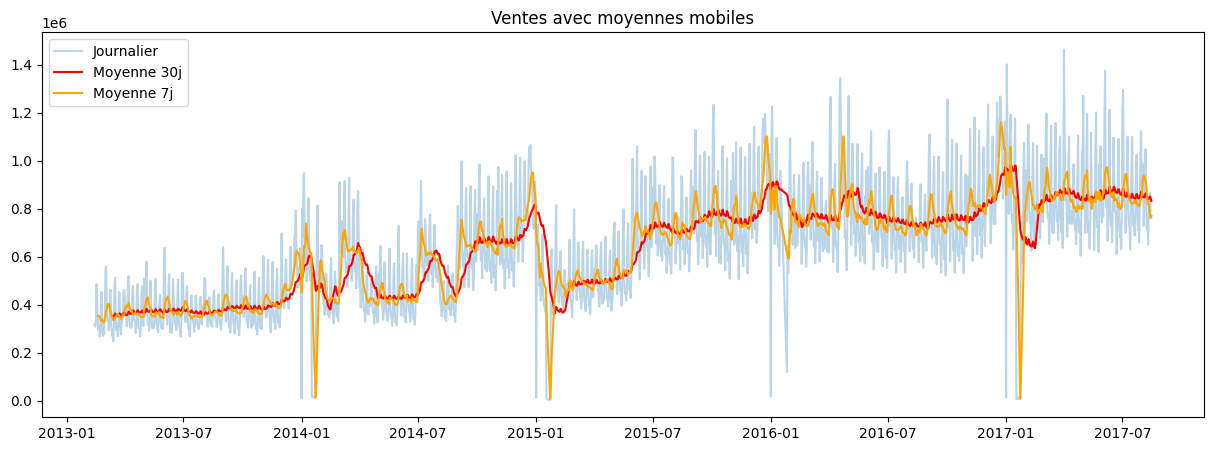

In [17]:
daily = df_train.groupby('date')['sales'].sum()
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(daily.index, daily.values, alpha=0.3, label='Journalier')
ax.plot(daily.index, daily.rolling(30).mean(), color='red', label='Moyenne 30j')
ax.plot(daily.index, daily.rolling(7).mean(), color='orange', label='Moyenne 7j')
ax.legend()
ax.set_title("Ventes avec moyennes mobiles")
plt.show()

## Sales by day of the week

This visualization compares the distribution of sales across the days of the week.

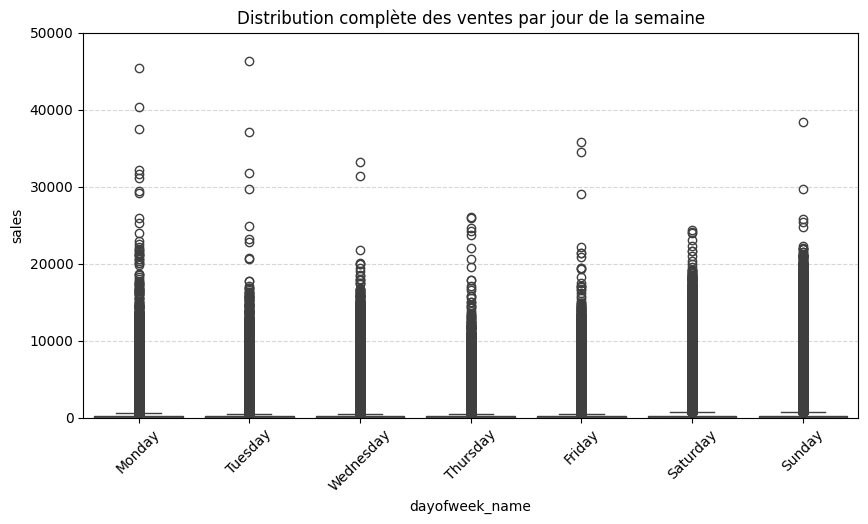

In [ ]:

df_train['dayofweek_name'] = df_train['date'].dt.day_name()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_train, x='dayofweek_name', y='sales',
            order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.title("Distribution complète des ventes par jour de la semaine")
plt.xticks(rotation=45)
plt.ylim(0, 50000) # Ajusté à 5000 car 50000 est souvent trop haut pour voir les boîtes
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


## Average sales by month

This chart shows the average sales for each month and helps identify seasonal patterns.

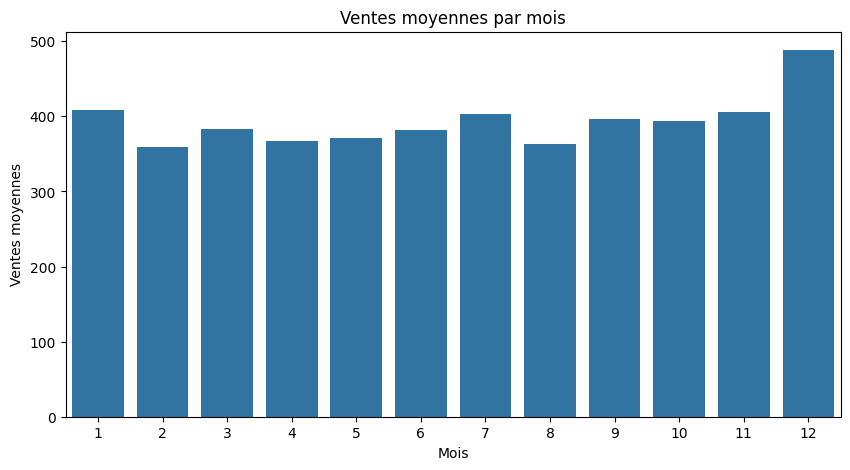

In [19]:
df_train['month_name'] = df_train['date'].dt.month_name()

monthly = df_train.groupby('month')['sales'].mean()
plt.figure(figsize=(10, 5))
sns.barplot(x=monthly.index, y=monthly.values)
plt.title("Ventes moyennes par mois")
plt.xlabel("Mois")
plt.ylabel("Ventes moyennes")
plt.show()

## Weekly and monthly seasonality

This heatmap shows average sales by day of the week and month.

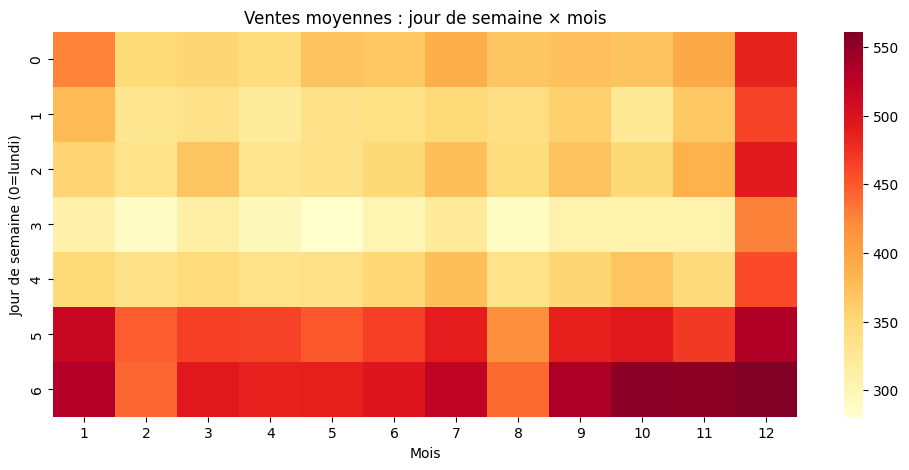

In [20]:
pivot = df_train.pivot_table(values='sales', index='dayofweek',
                       columns='month', aggfunc='mean')

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0f')
plt.title("Ventes moyennes : jour de semaine × mois")
plt.xlabel("Mois")
plt.ylabel("Jour de semaine (0=lundi)")
plt.show()

## Sales by product family

This chart ranks product families according to their total sales contribution.

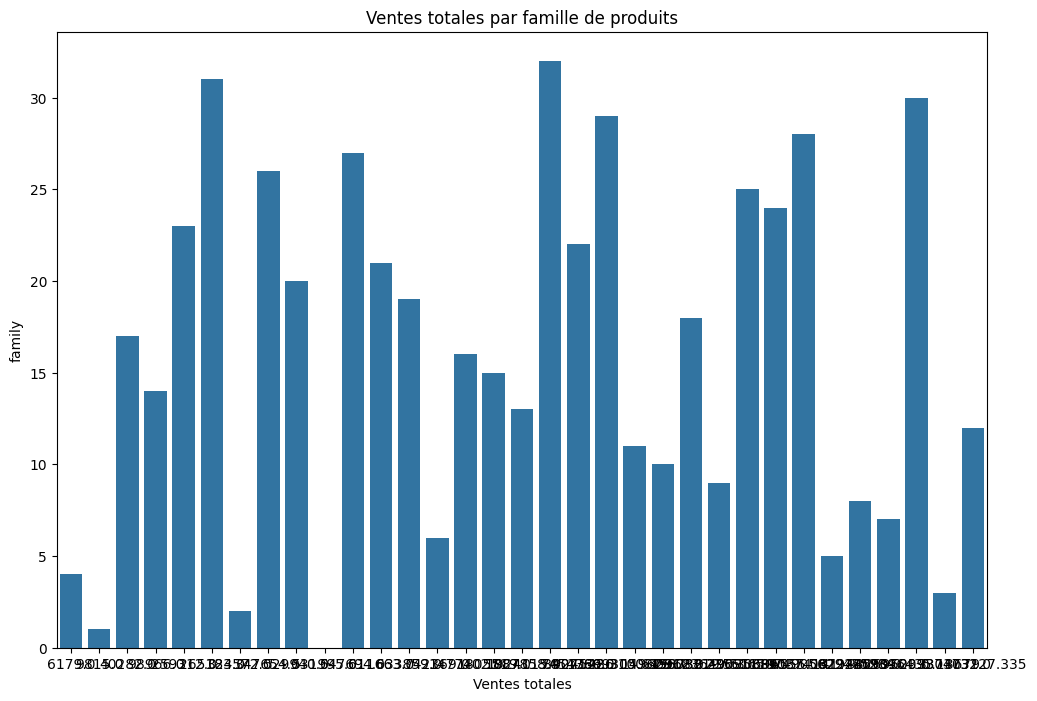

In [21]:
family_sales = df_train.groupby('family')['sales'].sum().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(x=family_sales.values, y=family_sales.index)
plt.title("Ventes totales par famille de produits")
plt.xlabel("Ventes totales")
plt.show()

## Sales by store

This chart compares the total sales generated by each store.

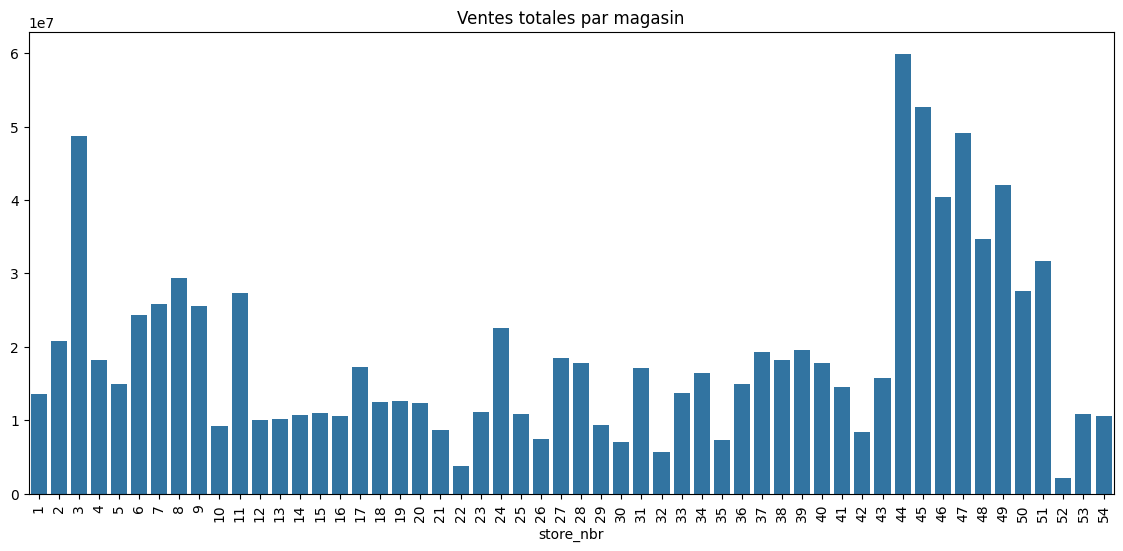

In [22]:
store_sales = df_train.groupby('store_nbr')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(x=store_sales.index, y=store_sales.values)
plt.title("Ventes totales par magasin")
plt.xticks(rotation=90)
plt.show()

## Sales by state

This chart compares total sales across the different states.

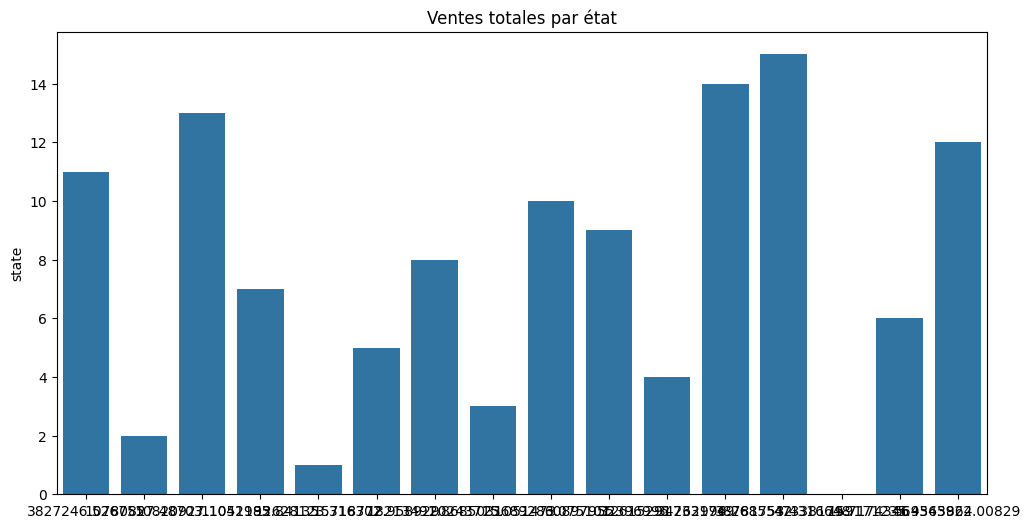

In [23]:
state_sales = df_train.groupby('state')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=state_sales.values, y=state_sales.index)
plt.title("Ventes totales par état")
plt.show()

## Holiday impact analysis

These charts compare average sales when each holiday or event indicator is active or inactive.

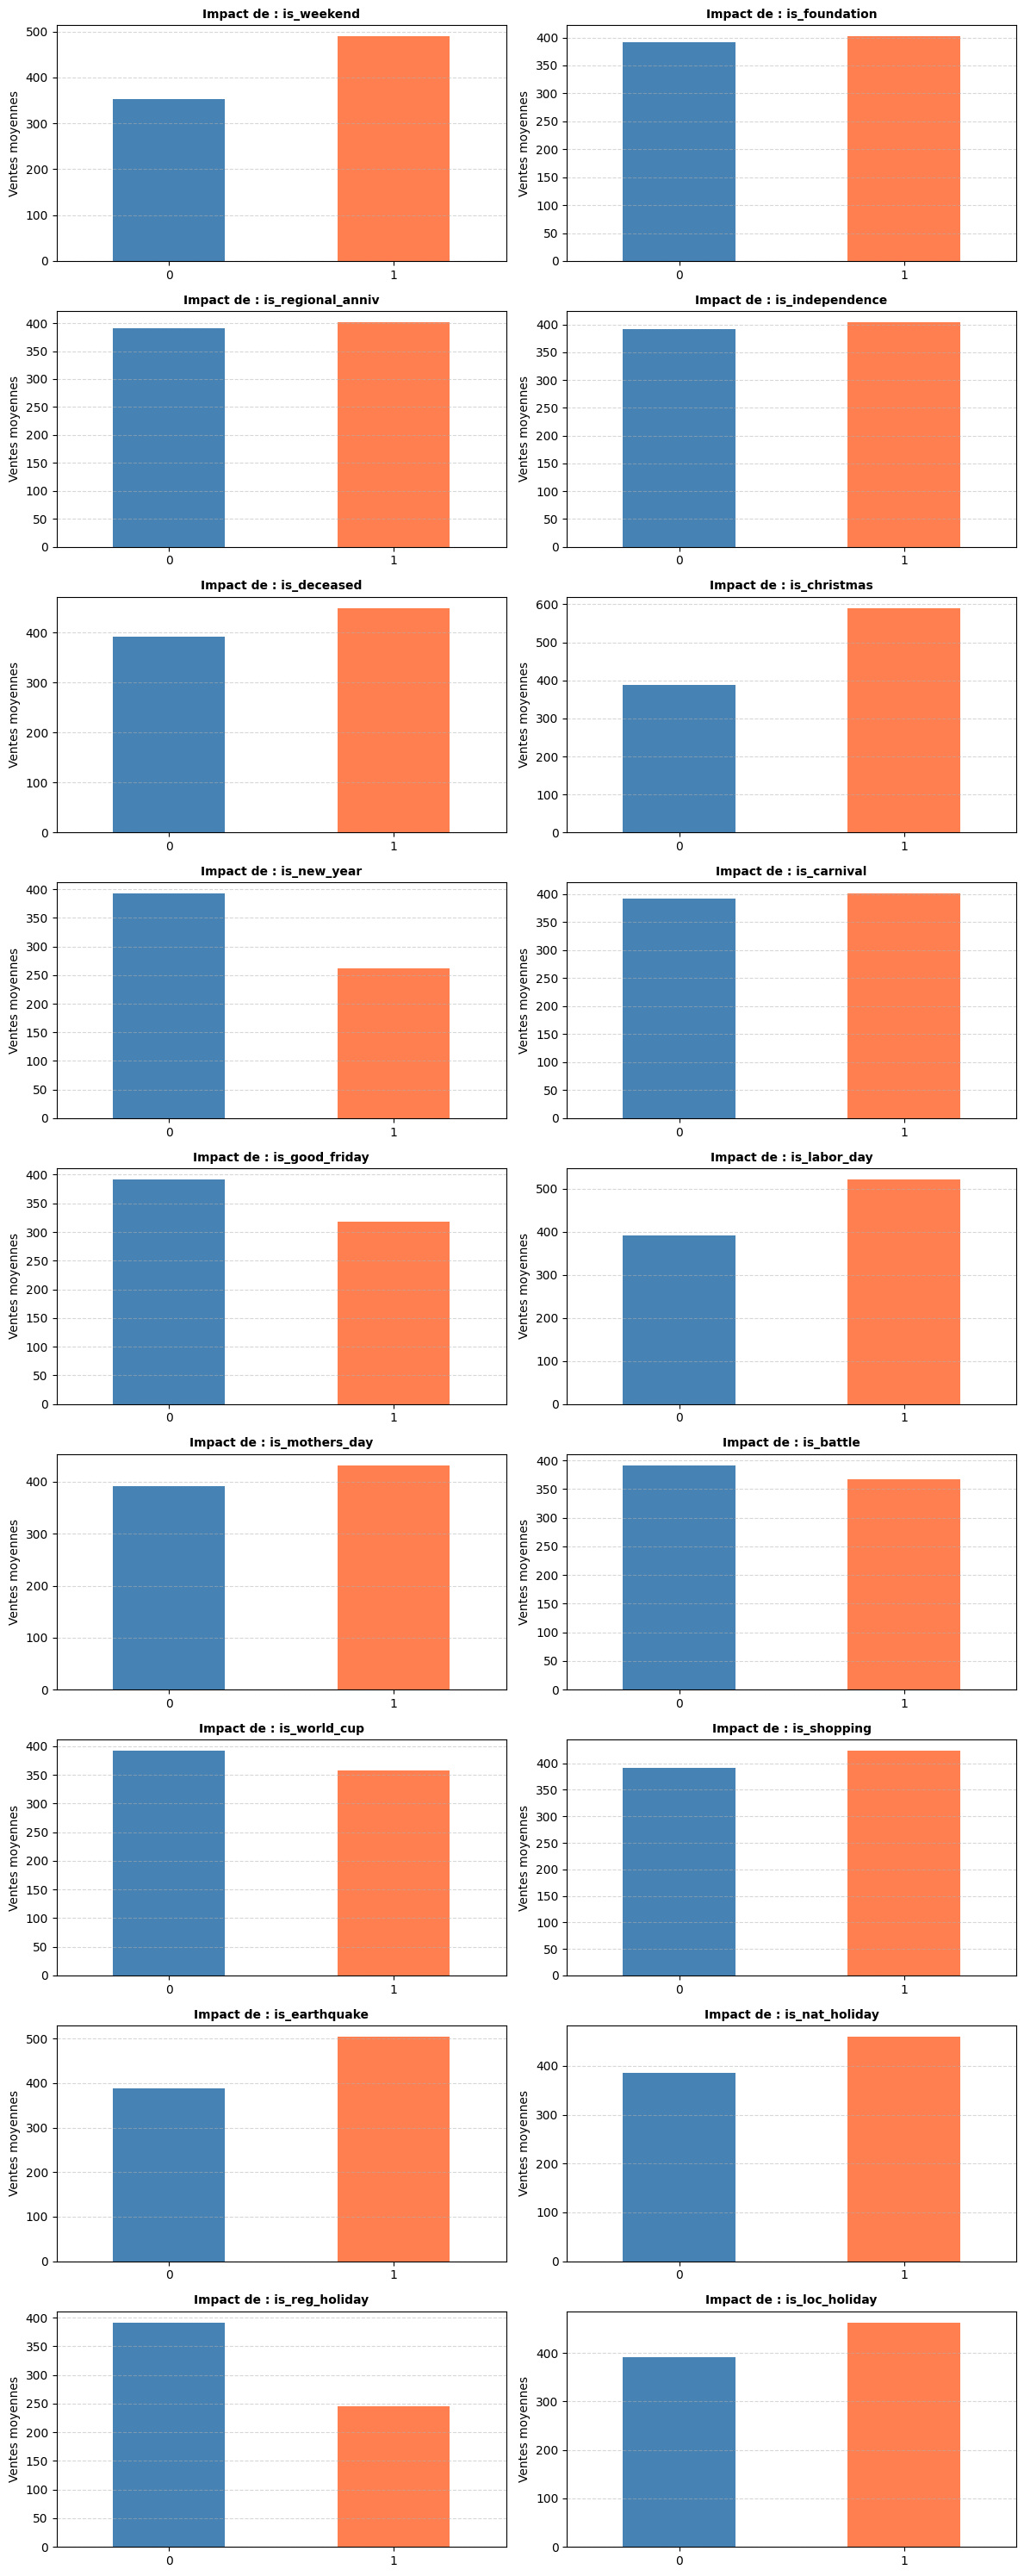

In [ ]:

holiday_cols = [
    'is_weekend', 'is_foundation', 'is_regional_anniv', 'is_independence', 
    'is_deceased', 'is_christmas', 'is_new_year', 'is_carnival', 
    'is_good_friday', 'is_labor_day', 'is_mothers_day', 'is_battle', 
    'is_world_cup', 'is_shopping', 'is_earthquake', 'is_nat_holiday', 
    'is_reg_holiday', 'is_loc_holiday'
]

fig, axes = plt.subplots(9, 2, figsize=(12, 30))

axes_plats = axes.flatten()

for ax, col in zip(axes_plats, holiday_cols):
    # Calcul de la moyenne des ventes
    means = df_train.groupby(col)['sales'].mean()
    
    # Tracé du graphique en barres
    means.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
    
    # Personnalisation esthétique
    ax.set_title(f"Impact de : {col}", fontsize=10, fontweight='bold')
    ax.set_xlabel("")
    ax.set_ylabel("Ventes moyennes")
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## Earthquake impact analysis

This visualization examines sales around the date of the Manabi earthquake to identify a possible short-term impact.

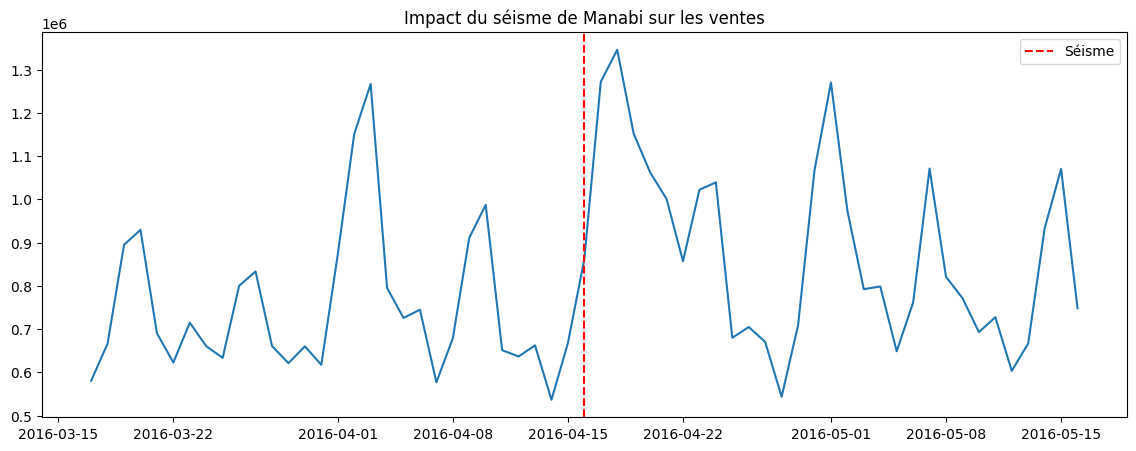

In [25]:
quake = pd.Timestamp('2016-04-16')
window = df_train[(df_train['date'] >= quake - pd.Timedelta(days=30)) &
            (df_train['date'] <= quake + pd.Timedelta(days=30))]

daily_window = window.groupby('date')['sales'].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_window.index, daily_window.values)
plt.axvline(quake, color='red', linestyle='--', label='Séisme')
plt.title("Impact du séisme de Manabi sur les ventes")
plt.legend()
plt.show()

## Available features

This cell lists the columns available in the processed training dataset.

In [26]:
df_train.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'city',
       'state', 'type', 'cluster', 'transactions', 'oil_price',
       'is_nat_holiday', 'is_reg_holiday', 'is_loc_holiday', 'year', 'month',
       'day', 'dayofweek', 'is_weekend', 'is_foundation', 'is_regional_anniv',
       'is_independence_cry', 'is_independence', 'is_moved', 'is_deceased',
       'is_christmas', 'is_new_year', 'is_carnival', 'is_good_friday',
       'is_labor_day', 'is_mothers_day', 'is_battle', 'is_world_cup',
       'is_shopping', 'is_earthquake', 'sales_lag_16', 'sales_lag_21',
       'sales_lag_28', 'sales_roll_mean_7_lag16', 'sales_roll_mean_28_lag16',
       'transactions_lag_16', 'transactions_roll_mean_7_lag16',
       'dayofweek_name', 'month_name'],
      dtype='object')

## Correlation analysis

This heatmap displays correlations between numerical variables and helps identify relationships and possible redundancy.

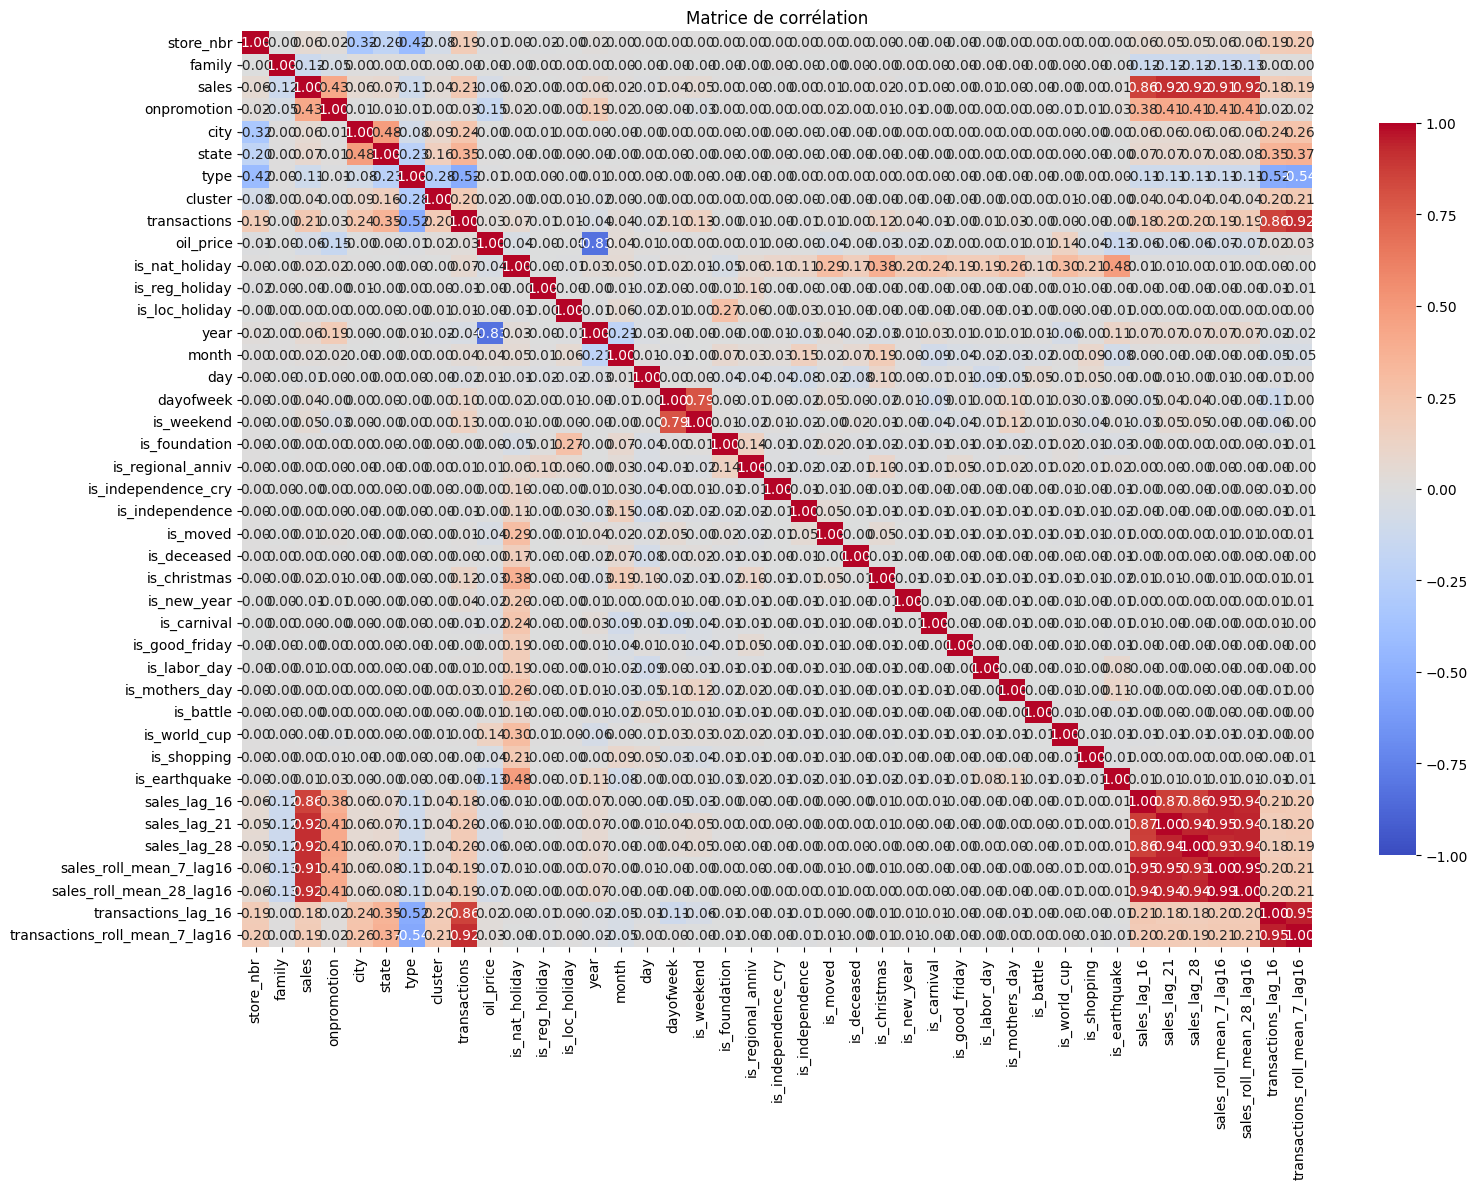

In [27]:

corr = df_train.drop(columns=["id"]).corr(numeric_only=True)

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
plt.title("Matrice de corrélation")
plt.tight_layout()

plt.savefig("matrice_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

## Feature selection

This cell removes identifiers, target-related columns, and variables that should not be used as model inputs.

In [65]:
# Les variables à exclure de l'entraînement
cols_a_exclure = [
    "id", "sales", "date",
    "transactions", 'is_foundation', 
    'is_regional_anniv', 'is_independence_cry', 
    'is_independence', 'is_moved', 'is_deceased', 'is_christmas',
    'is_carnival', 'is_good_friday', 'is_labor_day', 
    'is_mothers_day', 'is_battle', 'is_world_cup', 'is_shopping', 'is_earthquake'
]

# Sélection automatique des variables à utiliser
var = [x for x in df.columns if x not in cols_a_exclure]

print("Variables conservées pour l'entraînement :")
print(var)


Variables conservées pour l'entraînement :
['store_nbr', 'family', 'onpromotion', 'city', 'state', 'type', 'cluster', 'oil_price', 'is_nat_holiday', 'is_reg_holiday', 'is_loc_holiday', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'is_new_year', 'sales_lag_16', 'sales_lag_21', 'sales_lag_28', 'sales_roll_mean_7_lag16', 'sales_roll_mean_28_lag16', 'transactions_lag_16', 'transactions_roll_mean_7_lag16']


## Chronological data split

This cell separates training, validation, and evaluation periods in chronological order, which is appropriate for time-series forecasting.

In [66]:
# séparation des données:

# utiliser 60% des données comme training set et mettre les autres dans des var temp:
# x_train, x_, y_train, y_ = train_test_split(df_train[var], df_train["sales"], test_size=0.40, random_state=1)

# séparer les 40% restant en cross validation et test set
# x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.50, random_state=1)

max_date = df_train['date'].max()

cutoff_test = max_date - pd.Timedelta(days=16)      # frontière train+cv / test
cutoff_cv   = cutoff_test - pd.Timedelta(days=16)    # frontière train / cv

train_mask = df_train['date'] <= cutoff_cv
cv_mask    = (df_train['date'] > cutoff_cv) & (df_train['date'] <= cutoff_test)
test_mask  = df_train['date'] > cutoff_test

x_train, y_train = df_train.loc[train_mask, var], np.log1p(df_train.loc[train_mask, 'sales'])
x_cv,    y_cv    = df_train.loc[cv_mask, var],    np.log1p(df_train.loc[cv_mask, 'sales'])
x_test,  y_test  = df_train.loc[test_mask, var],  np.log1p(df_train.loc[test_mask, 'sales'])

print("La forme des features du training set", x_train.shape)
print("La forme de y_train", y_train.shape)
print("La forme de x_cv", x_cv.shape, "et de y_cv", y_cv.shape)
print("La forme de x_test", x_test.shape, "et de y_test", y_test.shape)

La forme des features du training set (2585121, 24)
La forme de y_train (2585121,)
La forme de x_cv (28512, 24) et de y_cv (28512,)
La forme de x_test (28512, 24) et de y_test (28512,)


## XGBoost model training

This cell configures and trains an XGBoost regressor using the logarithm of sales as the target. Early stopping limits overfitting.

In [67]:
# Configuration du modèle
xgb_model = xgb.XGBRegressor(
    n_estimators=5000, 
    learning_rate=0.03,
    verbosity=1, 
    random_state=1, 
    early_stopping_rounds=50,
    eval_metric="rmse",          # Une seule métrique pour cibler l'Early Stopping (RMSLE)
    enable_categorical=True,
)

# Entraînement
xgb_model.fit(
    x_train, 
    y_train, 
    eval_set=[(x_train, y_train), (x_cv, y_cv)],
    verbose=100                  # Affiche un résumé toutes les 100 étapes pour ne pas polluer l'écran
)

[0]	validation_0-rmse:2.59026	validation_1-rmse:2.50548
[100]	validation_0-rmse:0.63194	validation_1-rmse:0.43169
[200]	validation_0-rmse:0.56145	validation_1-rmse:0.40992
[300]	validation_0-rmse:0.53884	validation_1-rmse:0.40854
[400]	validation_0-rmse:0.52263	validation_1-rmse:0.40764
[500]	validation_0-rmse:0.51218	validation_1-rmse:0.40707
[600]	validation_0-rmse:0.50181	validation_1-rmse:0.40638
[700]	validation_0-rmse:0.49397	validation_1-rmse:0.40578
[800]	validation_0-rmse:0.48705	validation_1-rmse:0.40534
[900]	validation_0-rmse:0.48253	validation_1-rmse:0.40490
[1000]	validation_0-rmse:0.47586	validation_1-rmse:0.40466
[1100]	validation_0-rmse:0.46990	validation_1-rmse:0.40426
[1200]	validation_0-rmse:0.46376	validation_1-rmse:0.40400
[1300]	validation_0-rmse:0.46027	validation_1-rmse:0.40376
[1400]	validation_0-rmse:0.45704	validation_1-rmse:0.40344
[1475]	validation_0-rmse:0.45451	validation_1-rmse:0.40333


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=5000,
             n_jobs=None, num_parallel_tree=None, ...)

## Model predictions

This cell generates predictions for the evaluation period using the trained XGBoost model.

In [68]:
y_pred_test = xgb_model.predict(x_test)

In [69]:
import numpy as np

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
print(mae)
print(np.sqrt(mse))

0.2934978191279238
0.43299641863410876


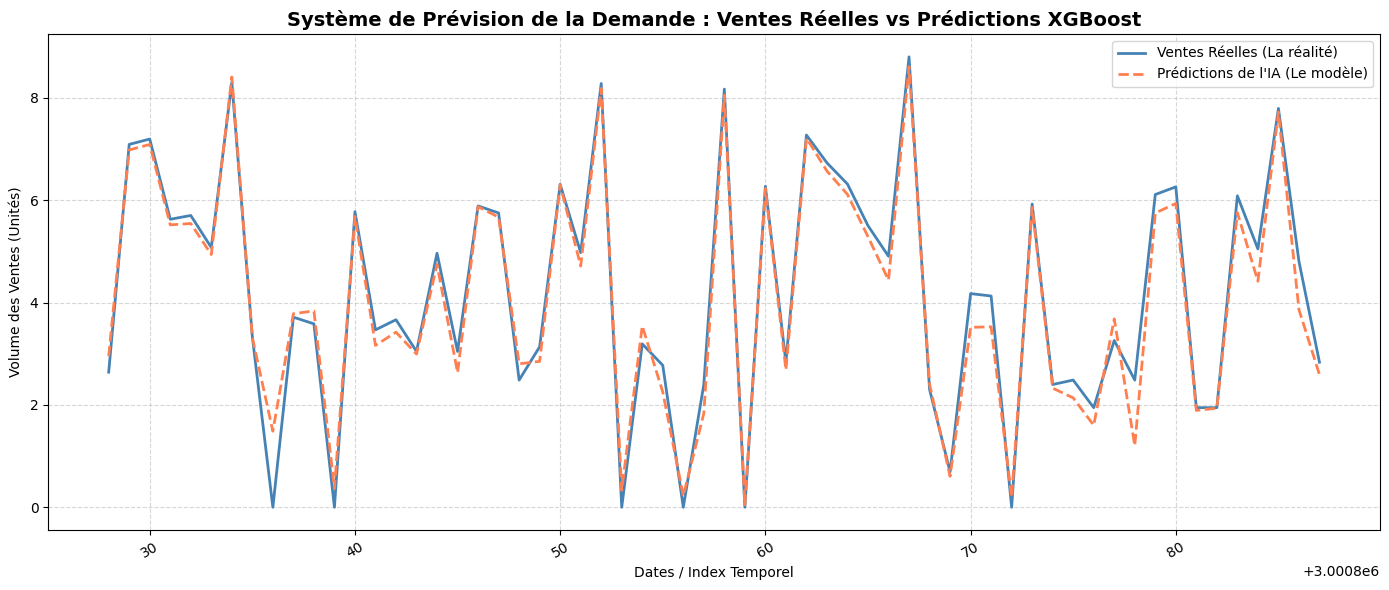

In [ ]:

df_visu = pd.DataFrame({
    'Ventes_Reelles': y_test.values,
    'Predictions': y_pred_test
}, index=y_test.index)

df_visu = df_visu.sort_index()

df_visu_zoom = df_visu.tail(60)

plt.figure(figsize=(14, 6))

plt.plot(df_visu_zoom.index, df_visu_zoom['Ventes_Reelles'], 
         label="Ventes Réelles (La réalité)", color="steelblue", linewidth=2)

plt.plot(df_visu_zoom.index, df_visu_zoom['Predictions'], 
         label="Prédictions de l'IA (Le modèle)", color="coral", linestyle="--", linewidth=2)

plt.title("Système de Prévision de la Demande : Ventes Réelles vs Prédictions XGBoost", fontsize=14, fontweight='bold')
plt.xlabel("Dates / Index Temporel")
plt.ylabel("Volume des Ventes (Unités)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig("courbe_previsions_reparee.png", dpi=300)
plt.show()


## Final feature list

This cell displays the variables used as inputs by the model.

In [34]:
print(var)

['store_nbr', 'family', 'onpromotion', 'city', 'state', 'type', 'cluster', 'oil_price', 'is_nat_holiday', 'is_reg_holiday', 'is_loc_holiday', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'is_foundation', 'is_regional_anniv', 'is_independence_cry', 'is_independence', 'is_moved', 'is_deceased', 'is_christmas', 'is_new_year', 'is_carnival', 'is_good_friday', 'is_labor_day', 'is_mothers_day', 'is_battle', 'is_world_cup', 'is_shopping', 'is_earthquake', 'sales_lag_16', 'sales_lag_21', 'sales_lag_28', 'sales_roll_mean_7_lag16', 'sales_roll_mean_28_lag16', 'transactions_lag_16', 'transactions_roll_mean_7_lag16']


## Feature importance

This chart displays the fifteen features that contribute most to the XGBoost predictions.

/tmp/ipykernel_58/3662138646.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top_n, palette='viridis')


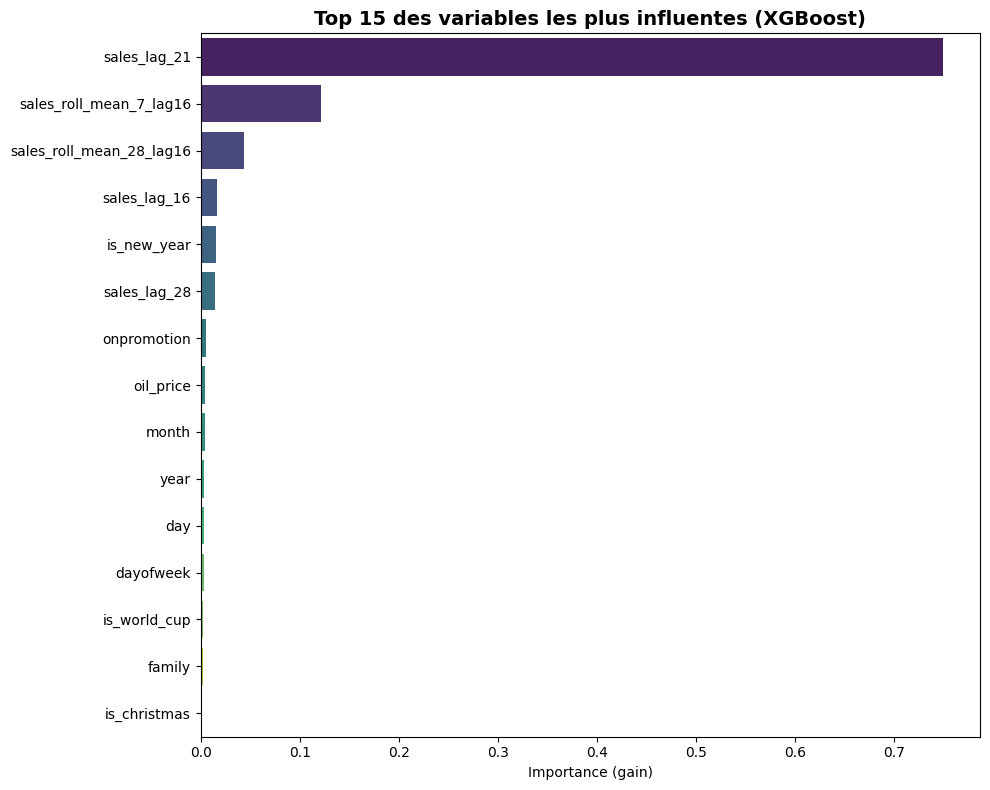

In [37]:
# Récupération de l'importance des features du modèle XGBoost
importances = xgb_model.feature_importances_
feat_imp = pd.DataFrame({
    'feature': var,
    'importance': importances
}).sort_values('importance', ascending=False)

# On garde les 15 features les plus importantes pour la lisibilité
top_n = feat_imp.head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=top_n, palette='viridis')
plt.title("Top 15 des variables les plus influentes (XGBoost)", fontsize=14, fontweight='bold')
plt.xlabel("Importance (gain)")
plt.ylabel("")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

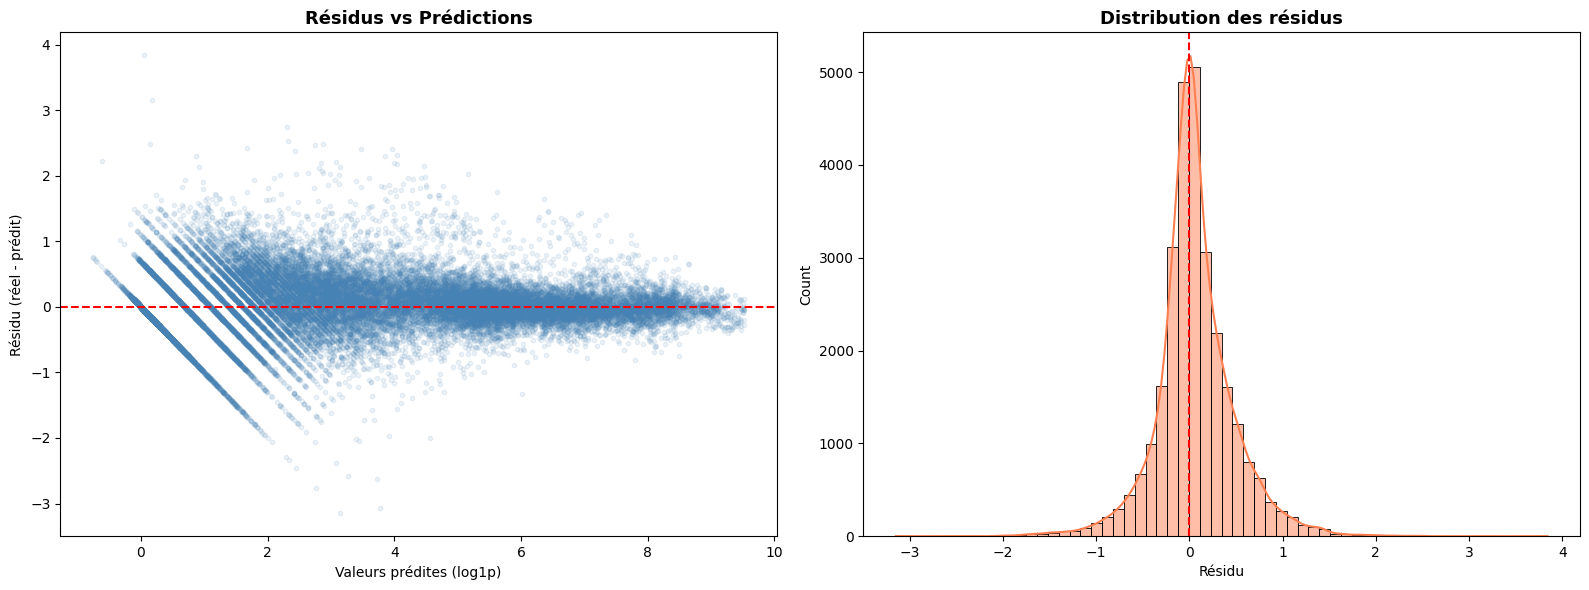

In [38]:
# Calcul des résidus (en espace log, comme le modèle)
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Résidus vs valeurs prédites — pour détecter un biais systématique
axes[0].scatter(y_pred_test, residuals, alpha=0.1, s=10, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Résidus vs Prédictions", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Valeurs prédites (log1p)")
axes[0].set_ylabel("Résidu (réel - prédit)")

# Distribution des résidus — pour vérifier qu'ils sont centrés autour de 0
sns.histplot(residuals, bins=60, kde=True, color="coral", ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Distribution des résidus", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Résidu")

plt.tight_layout()
plt.savefig("residus_analyse.png", dpi=300)
plt.show()

## Future sales forecasting

This cell applies the trained model to the future test observations.

In [35]:
y_r_test = xgb_model.predict(df_test[var])

## Future forecast visualization

This chart compares recent historical sales with the forecasted sales for the future period.

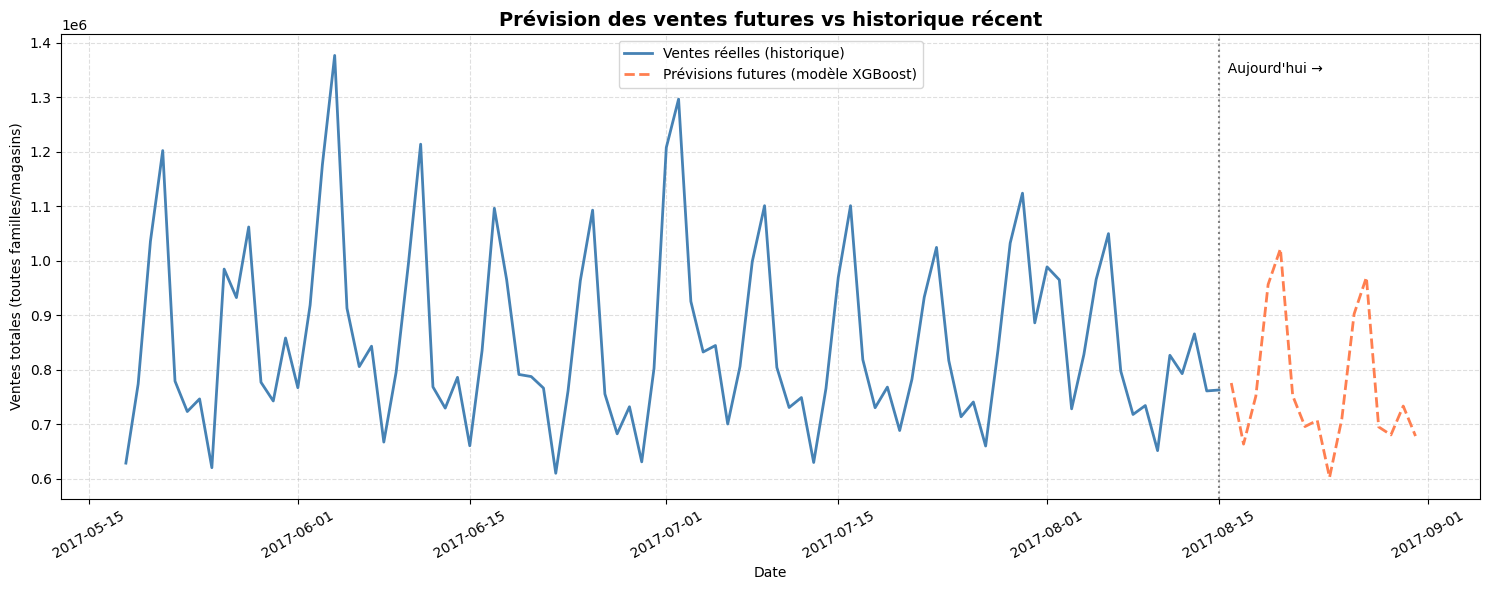

In [72]:
# 1. Agréger les prédictions par date (toutes familles/magasins confondus)
df_test_visu = df_test[['date']].copy()
df_test_visu['sales_predicted'] = np.clip(np.expm1(y_r_test), 0, None)

daily_forecast = df_test_visu.groupby('date')['sales_predicted'].sum()

# 2. Récupérer l'historique récent réel pour donner du contexte (ex: 90 derniers jours)
daily_historical = df_train.groupby('date')['sales'].sum().tail(90)

# 3. Tracer les deux à la suite
plt.figure(figsize=(15, 6))

plt.plot(daily_historical.index, daily_historical.values, 
         label="Ventes réelles (historique)", color="steelblue", linewidth=2)

plt.plot(daily_forecast.index, daily_forecast.values, 
         label="Prévisions futures (modèle XGBoost)", color="coral", linewidth=2, linestyle="--")

# Ligne verticale pour marquer la frontière passé/futur
plt.axvline(daily_historical.index.max(), color="gray", linestyle=":", linewidth=1.5)
plt.text(daily_historical.index.max(), plt.ylim()[1]*0.95, "  Aujourd'hui →", fontsize=10)

plt.title("Prévision des ventes futures vs historique récent", fontsize=14, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Ventes totales (toutes familles/magasins)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("previsions_futures.png", dpi=300)
plt.show()

## Submission file creation

This cell creates the final CSV file containing the observation identifiers and predicted sales values.

In [36]:
submission = pd.DataFrame({
    'id': df_test['id'],
    'sales': np.clip(np.expm1(y_r_test), 0, None)
})
submission.to_csv('submission.csv', index=False)